In [1]:
import slicersim

# SN Ia

In [2]:
snia = slicersim.LazuliSN(redshift=0.8, c=0.2, x1=-1.2, phase=1.5)

In [3]:
config, reached_snr = snia.setup_to_snr(20)

In [4]:
# update the simulation (see sim.mutable_parameters)
snia.set_properties(redshift=0.8)
lbda, flux_1, variance_1 = snia.get_spectrum(unit="adu")

snia.set_properties(redshift=1.2)
lbda, flux_2, variance_2 = snia.get_spectrum(unit="adu")

[Text(0.5, 0, 'wavelength [$\\AA$]'), Text(0, 0.5, 'flux [ADU]')]

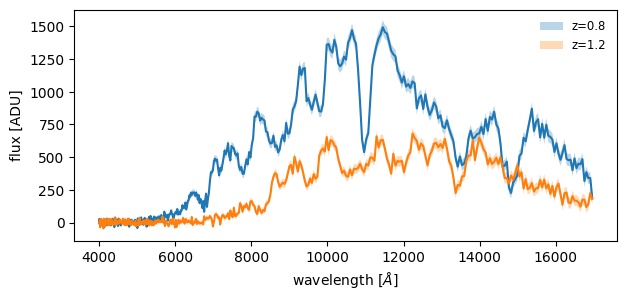

In [5]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=[7,3])

ax.plot(lbda, flux_1)
ax.fill_between(lbda, 
                flux_1-np.sqrt(variance_1),
                flux_1+np.sqrt(variance_1), alpha=0.3,
               label="z=0.8")

ax.plot(lbda, flux_2)
ax.fill_between(lbda, 
                flux_2-np.sqrt(variance_2),
                flux_2+np.sqrt(variance_2), alpha=0.3,
               label="z=1.2")
ax.legend(frameon=False, fontsize="small")
ax.set(xlabel=r"wavelength [$\AA$]", ylabel="flux [ADU]")

# Any Target: BD17 example

In [19]:
calspec_bd17 = "https://archive.stsci.edu/hlsps/reference-atlases/cdbs/current_calspec/bd_17d4708_stisnic_007.fits"
import pandas
from astropy.io import fits

bd17 = pandas.DataFrame( fits.open(calspec_bd17)[1].data )
bd17 = bd17.set_index(bd17.index.values)
flag = bd17["WAVELENGTH"].between(3_000, 20_000).astype(bool).values
lbda_ref = bd17["WAVELENGTH"].astype(float).values[flag]
flux_ref = bd17["FLUX"].astype(float).values[flag]


In [20]:
from glob import glob

In [21]:
glob("https://archive.stsci.edu/hlsps/reference-atlases/cdbs/current_calspec/*")

[]